# Python with MongoDB

Helpful learning resources: https://www.tutorialspoint.com/mongodb/index.htm

## Libraries and Settings

In [1]:
"""Connect to MongoDB, insert restaurant data, run queries, and visualize results."""

# Libraries
import json
import os
import platform
import warnings
from datetime import datetime
from platform import python_version

import matplotlib.pyplot as plt
import pandas as pd
from pymongo import MongoClient
from pymongo.errors import PyMongoError

# Settings
warnings.filterwarnings("ignore")

# Use dark background for plots
plt.style.use("dark_background")

# Current working directory
print(os.getcwd())

/workspace


## Connect to the MongoDB server and list databases

In [2]:
# Connect to the MongoDB server
client = MongoClient("mongodb://mongo:27017/")

# List databases
databases = client.list_database_names()
print("Connected to MongoDB. Databases:", databases)

Connected to MongoDB. Databases: ['admin', 'config', 'local']


## Read and insert data

In [3]:
# Create / access the specific database and collection
db = client["restaurant_database"]
collection = db["restaurant_collection"]

# Read data from JSON file
with open(
    "/workspace/data/restaurant_data.json", "r", encoding="utf-8"
) as file:
    example_data = json.load(file)

# Insert data into the collection (similar to tables in an SQL database)
try:
    insert_result = collection.insert_many(example_data)
    print("Inserted documents to MongoDB")
except PyMongoError as error:
    print(f"Insert error: {error}")

Inserted documents to MongoDB


## Define a query using MongoDB Query Language (MQL)

In [4]:
# Function to query the data
def query_collection(database_name, coll_name, mongo_query, mongo_client=client):
    """Run a find query against a MongoDB collection and return the results."""
    if mongo_client:
        database = mongo_client[database_name]
        coll = database[coll_name]
        query_results = list(coll.find(mongo_query))
        return query_results
    return []

# Define a query with multiple conditions
query = {
    "properties.addr:city": {"$in": ["Zürich", "Winterthur"]},
    "properties.amenity": "restaurant",
    "properties.cuisine": {"$in": ["burger", "pizza"]},
}

# Execute the query and fetch the results
results = query_collection(
    "restaurant_database",
    "restaurant_collection",
    query,
)
print("Query result:")
for result in results:
    print(result)

# Convert the results into a Pandas DataFrame
data = []
for result in results:
    properties = result["properties"]
    data.append(
        {
            "street": properties.get("addr:street"),
            "housenumber": properties.get("addr:housenumber"),
            "postcode": properties.get("addr:postcode"),
            "city": properties.get("addr:city"),
            "amenity": properties.get("amenity"),
            "cuisine": properties.get("cuisine"),
        }
    )

# Create a DataFrame from the list of dictionaries
df = pd.DataFrame(data)

# Display the DataFrame
df.head()

Query result:
{'_id': ObjectId('6aa7bb475e46d67f8021f4ad'), 'type': 'Feature', 'properties': {'@id': 'way/39374814', 'addr:city': 'Winterthur', 'addr:housenumber': '40', 'addr:postcode': '8400', 'addr:street': 'Lindstrasse', 'amenity': 'restaurant', 'building': 'apartments', 'building:levels': '4', 'capacity': '70', 'check_date:opening_hours': '2022-03-21', 'cuisine': 'pizza', 'delivery': 'no', 'name': 'Friedtal', 'opening_hours': 'Mo-Fr 08:30-24:00; Sa 10:00-24:00', 'roof:levels': '1', 'roof:shape': 'flat', 'takeaway': 'no'}, 'geometry': {'type': 'Polygon', 'coordinates': [[[8.7231586, 47.5094355], [8.7233191, 47.509261], [8.7234407, 47.5093147], [8.7234999, 47.5093747], [8.7234382, 47.5094314], [8.7233605, 47.5093947], [8.7232812, 47.5094856], [8.7231586, 47.5094355]]]}, 'id': 'way/39374814'}
{'_id': ObjectId('6aa7bb475e46d67f802201b8'), 'type': 'Feature', 'properties': {'@id': 'node/266864505', 'addr:city': 'Zürich', 'addr:housenumber': '30', 'addr:postcode': '8600', 'addr:street': 

,street,housenumber,postcode,city,amenity,cuisine
0,Lindstrasse,40,8400,Winterthur,restaurant,pizza
1,Zürichstrasse,30,8600,Zürich,restaurant,pizza
2,Limmatquai,16,8001,Zürich,restaurant,pizza
3,Waaggasse,5,8001,Zürich,restaurant,pizza
4,Regensbergstrasse,188,8050,Zürich,restaurant,pizza


## Define a query to aggregate the data using MongoDB Query Language (MQL)

In [5]:
# Function to aggregate the number of restaurants by cuisine and city
def aggregate_restaurants_by_cuisine_and_city(
    database_name, coll_name, mongo_client=client
):
    """Aggregate restaurant counts grouped by city and cuisine."""
    database = mongo_client[database_name]
    coll = database[coll_name]

    pipeline = [
        {
            "$match": {
                "properties.addr:city": {
                    "$in": ["Zürich", "Winterthur"]
                },
                "properties.cuisine": {"$in": ["burger", "pizza"]},
            }
        },
        {
            "$group": {
                "_id": {
                    "city": "$properties.addr:city",
                    "cuisine": "$properties.cuisine",
                },
                "count": {"$sum": 1},
            }
        },
        {"$sort": {"count": -1}},
    ]

    aggregation_results = list(coll.aggregate(pipeline))
    return aggregation_results


# Execute the aggregation query
results = aggregate_restaurants_by_cuisine_and_city(
    "restaurant_database",
    "restaurant_collection",
)
print("Query result:")
for result in results:
    print(result)

# Convert the results into a Pandas DataFrame
df = pd.DataFrame(results)

# Normalize the '_id' field to separate columns
df = pd.concat([df.drop(["_id"], axis=1), df["_id"].apply(pd.Series)], axis=1)

# Display the DataFrame
df  # pylint: disable=pointless-statement

Query result:
{'_id': {'city': 'Zürich', 'cuisine': 'pizza'}, 'count': 27}
{'_id': {'city': 'Zürich', 'cuisine': 'burger'}, 'count': 19}
{'_id': {'city': 'Winterthur', 'cuisine': 'pizza'}, 'count': 8}
{'_id': {'city': 'Winterthur', 'cuisine': 'burger'}, 'count': 3}


,count,city,cuisine
0,27,Zürich,pizza
1,19,Zürich,burger
2,8,Winterthur,pizza
3,3,Winterthur,burger


## Make bar chart from results

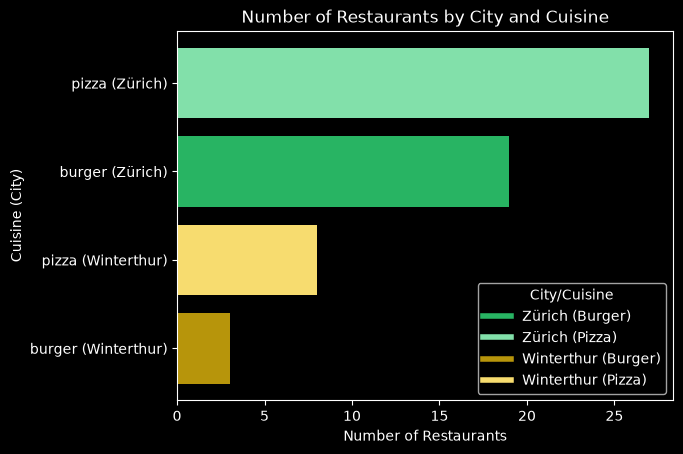

In [6]:
# Sort values in ascending order
df = df.sort_values(by="count", ascending=True)

# Define colors for each city and cuisine combination
colors = {
    ("Zürich", "burger"): "#28b463",
    ("Zürich", "pizza"): "#82e0aa",
    ("Winterthur", "burger"): "#b7950b",
    ("Winterthur", "pizza"): "#f7dc6f",
}

# Create a bar chart
fig, ax = plt.subplots()

# Plot data
for city in df["city"].unique():
    city_data = df[df["city"] == city]
    ax.barh(
        city_data["cuisine"] + " (" + city + ")",
        city_data["count"],
        color=[
            colors[(city, cuisine)]
            for cuisine in city_data["cuisine"]
        ],
        label=city,
    )

# Add labels and title
ax.set_xlabel("Number of Restaurants")
ax.set_ylabel("Cuisine (City)")
ax.set_title("Number of Restaurants by City and Cuisine")

# Create custom legend
handles = [
    plt.Line2D(
        [0], [0], color=list(colors.values())[0], lw=4,
        label="Zürich (Burger)",
    ),
    plt.Line2D(
        [0], [0], color=list(colors.values())[1], lw=4,
        label="Zürich (Pizza)",
    ),
    plt.Line2D(
        [0], [0], color=list(colors.values())[2], lw=4,
        label="Winterthur (Burger)",
    ),
    plt.Line2D(
        [0], [0], color=list(colors.values())[3], lw=4,
        label="Winterthur (Pizza)",
    ),
]
ax.legend(handles=handles, title="City/Cuisine")

# Show the plot
plt.show()

## Drop defined collections and databases

In [7]:
# List databases
databases = client.list_database_names()
print("Connected to MongoDB. Databases:", databases)

# Drop the defined collection and database if they exist
DB_NAME = "restaurant_database"
COLLECTION_NAME = "restaurant_collection"

db = client[DB_NAME]
if COLLECTION_NAME in db.list_collection_names():
    db.drop_collection(COLLECTION_NAME)
    print(
        f"Collection '{COLLECTION_NAME}' dropped from database "
        f"'{DB_NAME}'."
    )
else:
    print(
        f"Collection '{COLLECTION_NAME}' does not exist in database "
        f"'{DB_NAME}'."
    )

# Drop the database
if DB_NAME in databases:
    client.drop_database(DB_NAME)
    print(f"Database '{DB_NAME}' dropped.")
else:
    print(f"Database '{DB_NAME}' does not exist.")

Connected to MongoDB. Databases: ['admin', 'config', 'local', 'restaurant_database']
Collection 'restaurant_collection' dropped from database 'restaurant_database'.
Database 'restaurant_database' dropped.


### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [8]:
print("-" * 35)
print(os.name.upper())
print(platform.system(), "|", platform.release())
print("Datetime:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Python Version:", python_version())
print("-" * 35)

-----------------------------------
POSIX
Linux | 6.8.0-1064-azure
Datetime: 2026-09-14 09:15:52
Python Version: 3.11.16
-----------------------------------
